Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

Load Dataset

In [2]:
file_path = "../data/raw/Guns incident Data.csv"
df = pd.read_csv(file_path)

# Basic Data Overview

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100798 entries, 0 to 100797
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   S.No.               100798 non-null  int64  
 1   Year                100798 non-null  int64  
 2   Month               100798 non-null  int64  
 3   Date                100798 non-null  object 
 4   Reason              100798 non-null  object 
 5   Education           99376 non-null   object 
 6   Sex                 100798 non-null  object 
 7   Age                 100780 non-null  float64
 8   Race                100798 non-null  object 
 9   Hispanic            100798 non-null  int64  
 10  Place of incident   99414 non-null   object 
 11  Police involvement  100798 non-null  int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 9.2+ MB


,S.No.,Year,Month,Age,Hispanic,Police involvement
count,100798.000000,100798.000000,100798.000000,100780.000000,100798.000000,100798.000000
mean,50399.500000,2018.000357,6.567601,44.857601,114.179607,0.013909
std,29098.020554,0.816278,3.405609,19.496181,61.595734,0.117114
min,1.000000,2017.000000,1.000000,1.000000,100.000000,0.000000
25%,25200.250000,2017.000000,4.000000,28.000000,100.000000,0.000000
50%,50399.500000,2018.000000,7.000000,43.000000,100.000000,0.000000
75%,75598.750000,2019.000000,9.000000,59.000000,100.000000,0.000000
max,100798.000000,2019.000000,12.000000,108.000000,998.000000,1.000000


There are 100798 rows of data, with 12 columns.

# Univariate Analysis

## (a) Age Distribution

Text(0.5, 1.0, "Distribution of Victims' Age")

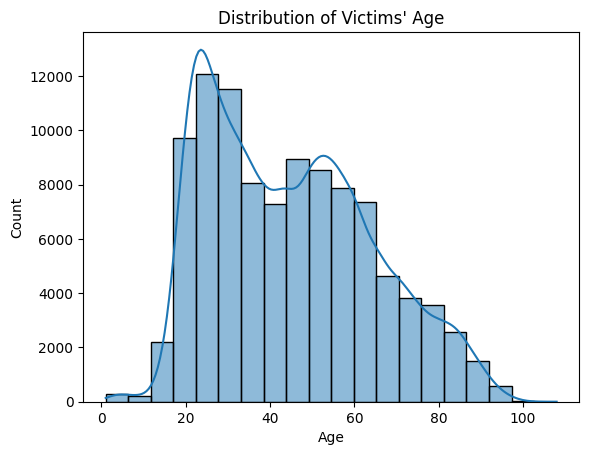

In [4]:
sns.histplot(df['Age'], kde=True, bins=20)
plt.title("Distribution of Victims' Age")

## (b) Sex Distribution

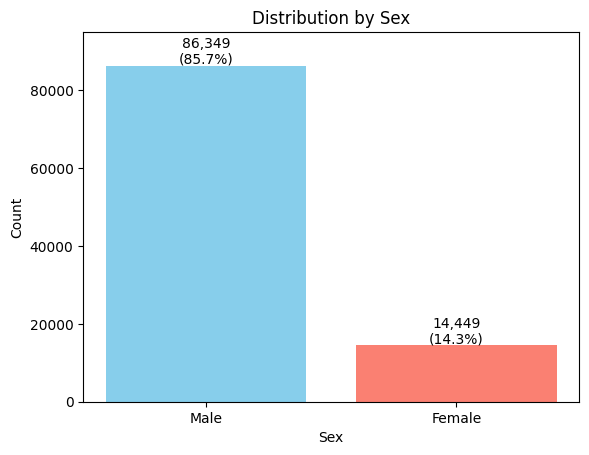

In [5]:
# Calculate counts and percentage
sex_counts = df['Sex'].value_counts()
sex_percent = sex_counts / sex_counts.sum() * 100

plt.bar(sex_counts.index, sex_counts.values, color = ['skyblue', 'salmon'])

# Add percentage and count labels
for i in range(len(sex_counts)):
    plt.text(
        i, sex_counts.iloc[i] + 500,
        f"{sex_counts.iloc[i]:,}\n({sex_percent.iloc[i]:.1f}%)",
        ha='center', fontsize=10
    )

plt.title("Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.ylim(0, sex_counts.max() * 1.1)
plt.show()


## (c) Education Level

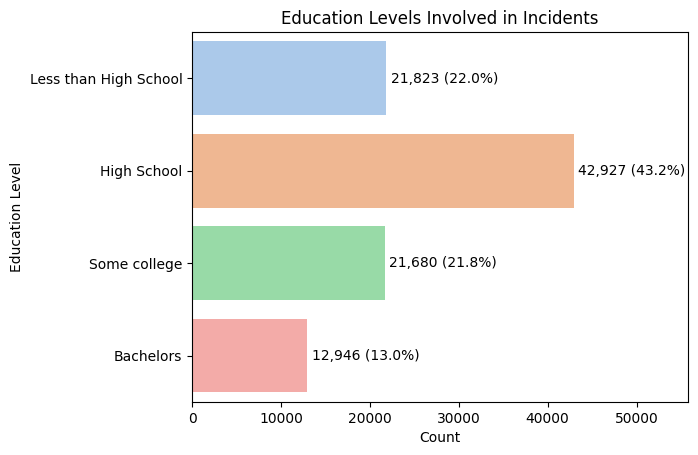

In [6]:
# Order of education
education_level = ['Less than High School', 'High School', 'Some college', 'Bachelors']

# Calculate counts and percentage
education_counts = df['Education'].value_counts()
education_percentage = education_counts / education_counts.sum() * 100

# Reorder to sequence in order of education
education_counts = education_counts.reindex(education_level)
education_percentage = education_percentage.reindex(education_level)

# Bar chart
bars = sns.barplot(
    y=education_counts.index,
    x=education_counts.values,
    hue=education_counts.index,
    palette=sns.color_palette("pastel", len(education_level)),
    legend=False
)

# Add count and percentage labels
for i in range(len(education_level)):
    plt.text(
        education_counts.iloc[i] + 500, i,
        f"{int(education_counts.iloc[i]):,} ({education_percentage.iloc[i]:.1f}%)",
        va='center', fontsize=10
    )

plt.title("Education Levels Involved in Incidents")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.xlim(0, education_counts.max() * 1.3)
plt.show()

## (d) Race

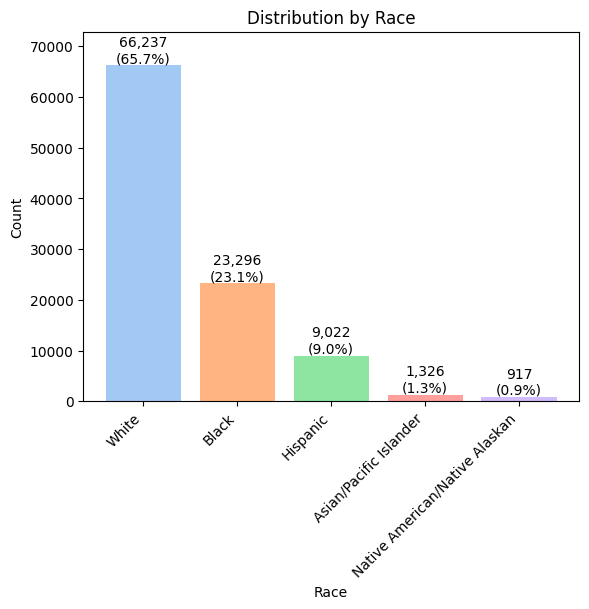

In [7]:
# Calculate counts and percentage
race_counts = df['Race'].value_counts()
race_percent = race_counts / race_counts.sum() * 100

plt.bar(race_counts.index, 
        race_counts.values, 
        color=sns.color_palette("pastel"))

# Add count and percentage labels
for i in range(len(race_counts)):
    plt.text(
        i, race_counts.iloc[i] + 500,
        f"{race_counts.iloc[i]:,}\n({race_percent.iloc[i]:.1f}%)",
        ha='center', fontsize=10
    )

plt.title("Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, race_counts.max() * 1.1)
plt.show()

# Bivariate Relationships

## (a) Age vs Reason

Text(0.5, 1.0, 'Age Distribution by Reason for Incident')

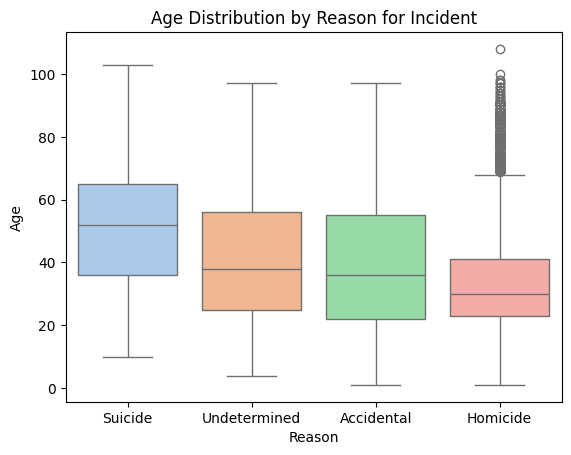

In [8]:
sns.boxplot(x = 'Reason', y = 'Age', data = df, palette = 'pastel', hue = 'Reason', legend = False)
plt.title("Age Distribution by Reason for Incident")

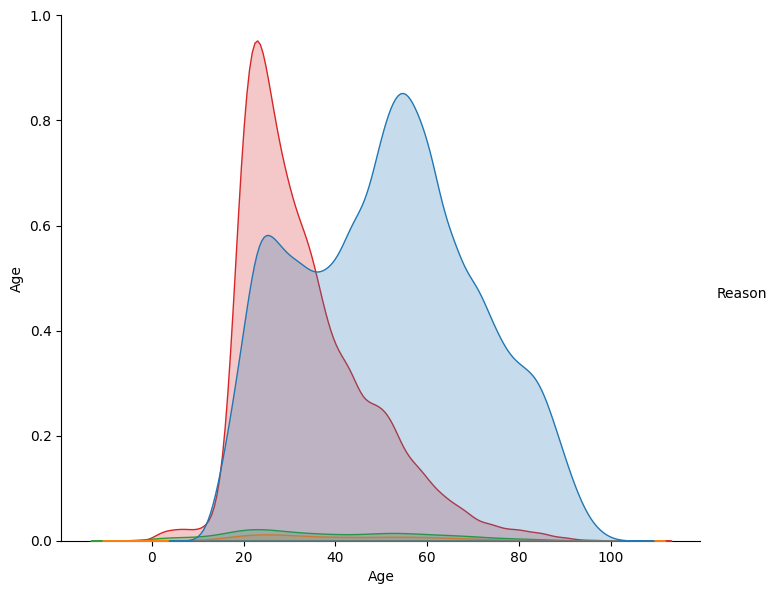

In [9]:
sns.pairplot(df, vars=['Age'], hue='Reason', height=6, aspect=1.2)

## (b) Sex vs Reason

Text(0.5, 1.0, 'Incident Reason by Sex')

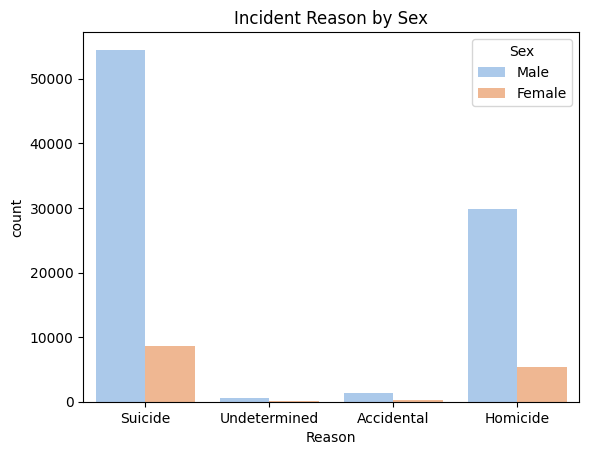

In [10]:
sns.countplot(x='Reason', hue='Sex', data=df, palette = 'pastel')
plt.title("Incident Reason by Sex")

## (c) Race vs Reason

Text(0.5, 1.0, 'Incident Reasons by Race')

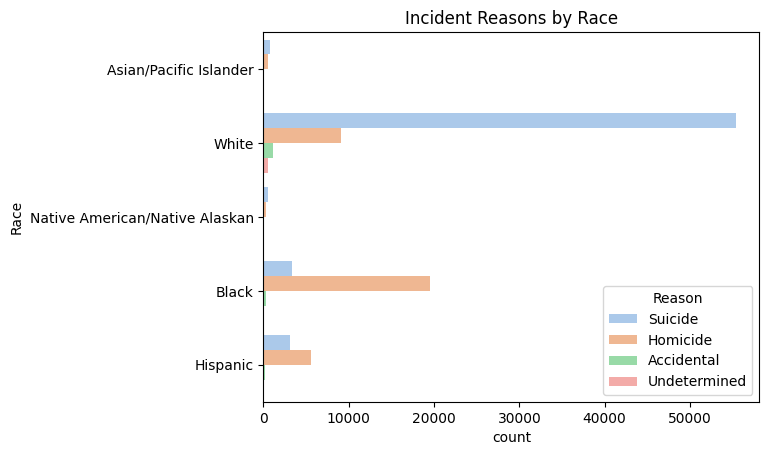

In [11]:
sns.countplot(y='Race', hue='Reason', data=df, palette = 'pastel', hue_order=['Suicide', 'Homicide', 'Accidental', 'Undetermined'])
plt.title("Incident Reasons by Race")

## (d) Education vs Reason

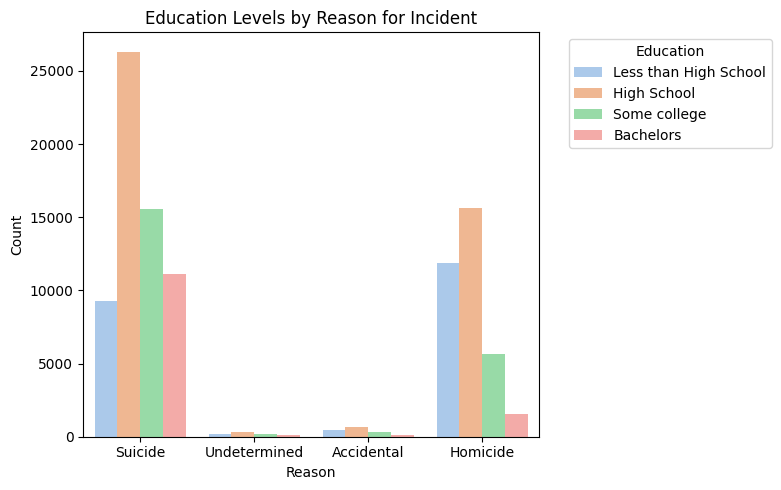

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='Reason',
    hue='Education',
    palette='pastel',
    hue_order = education_level
)

plt.title("Education Levels by Reason for Incident")
plt.xlabel("Reason")
plt.ylabel("Count")
plt.legend(title="Education", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


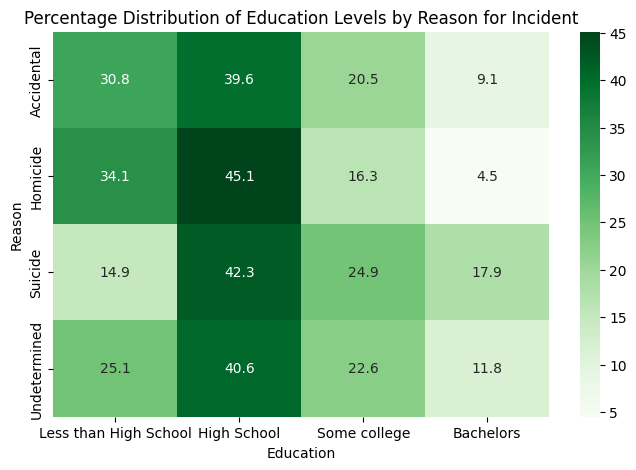

In [13]:
education_vs_reason = pd.crosstab(df['Reason'], df['Education'], normalize='index') * 100
education_vs_reason = education_vs_reason.reindex(columns = education_level)

plt.figure(figsize=(8,5))
sns.heatmap(education_vs_reason, annot = True, cmap = 'Greens', fmt = ".1f")
plt.title("Percentage Distribution of Education Levels by Reason for Incident")
plt.xlabel("Education")
plt.ylabel("Reason")
plt.show()

# Temporal patterns

## (a) Spread of Incidents


Date range: 2017-01-01 00:00:00 to 2019-12-28 00:00:00

Daily incident statistics:
count    1008.000000
mean       99.998016
std        11.185268
min        62.000000
25%        93.000000
50%       100.000000
75%       108.000000
max       142.000000
Name: incident_count, dtype: float64


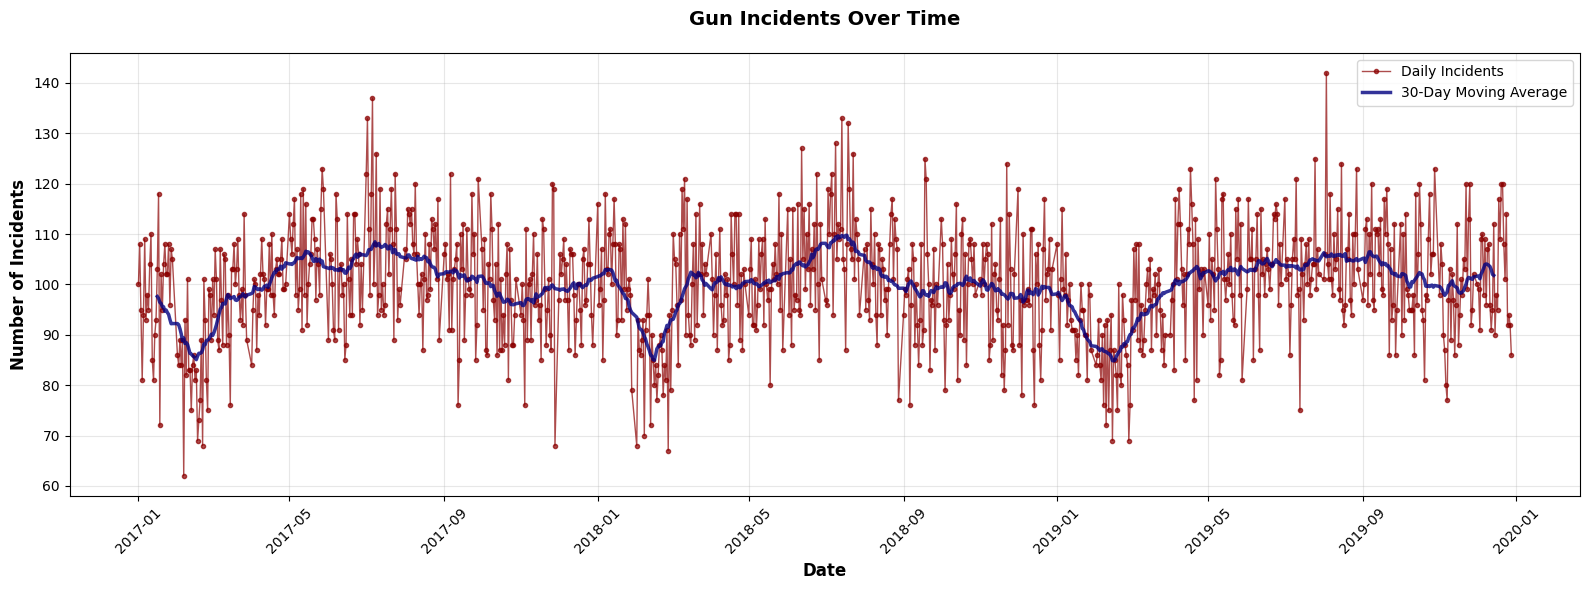

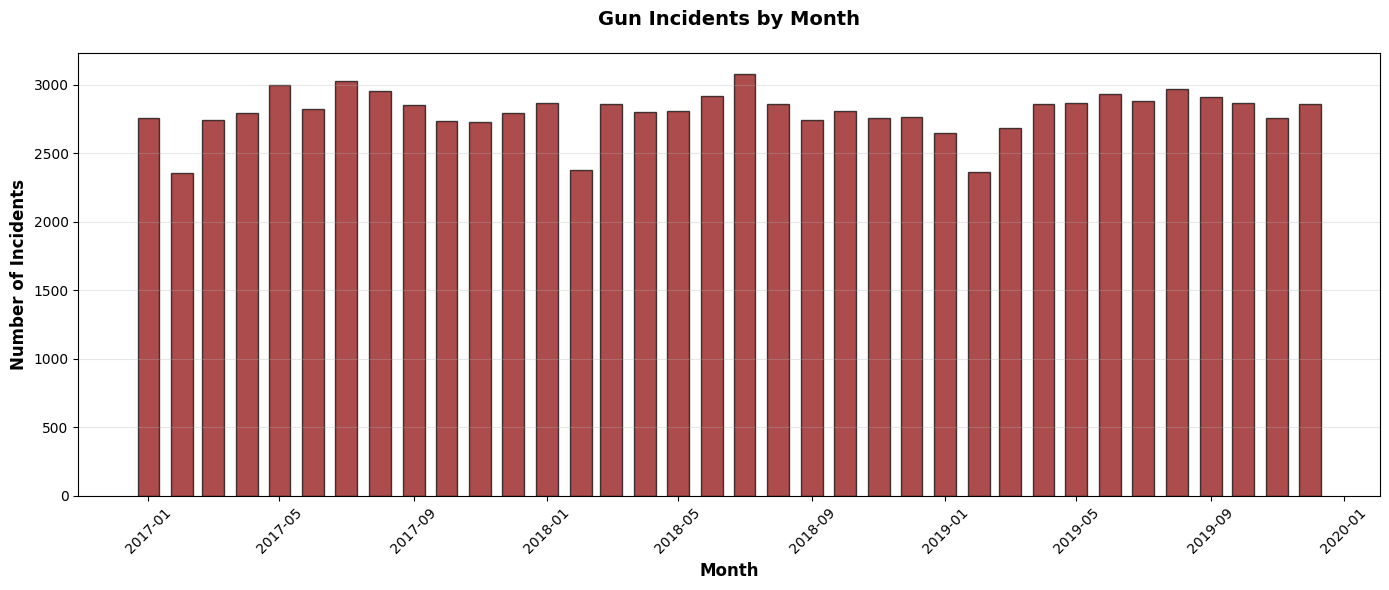


SUMMARY STATISTICS
Total incidents: 100798
Date range: 2017-01-01 to 2019-12-28
Total days covered: 1091
Average incidents per day: 100.00
Max incidents in a single day: 142
Date with most incidents: 2019-08-03


In [15]:
# Ensure Date column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Sort by date to ensure chronological order
df = df.sort_values('Date')

print("\nDate range:", df['Date'].min(), "to", df['Date'].max())

# Count incidents per day
daily_counts = df.groupby('Date').size().reset_index(name='incident_count')

print("\nDaily incident statistics:")
print(daily_counts['incident_count'].describe())

# Create the time series plot
fig, ax = plt.subplots(figsize=(16, 6))

# Plot the daily incident counts
ax.plot(daily_counts['Date'], daily_counts['incident_count'], 
        linewidth=1, alpha=0.7, color='darkred', marker='o', 
        markersize=3, label='Daily Incidents')

# Add a rolling average to show the trend
rolling_avg = daily_counts['incident_count'].rolling(window=30, center=True).mean()
ax.plot(daily_counts['Date'], rolling_avg, 
        linewidth=2.5, color='navy', alpha=0.8, 
        label='30-Day Moving Average')

# Formatting
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Incidents', fontsize=12, fontweight='bold')
ax.set_title('Gun Incidents Over Time', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Additional analysis: Monthly aggregation for clearer trends
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_counts = df.groupby('YearMonth').size().reset_index(name='incident_count')
monthly_counts['YearMonth'] = monthly_counts['YearMonth'].dt.to_timestamp()

# Create monthly plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(monthly_counts['YearMonth'], monthly_counts['incident_count'], 
       width=20, color='darkred', alpha=0.7, edgecolor='black')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Incidents', fontsize=12, fontweight='bold')
ax.set_title('Gun Incidents by Month', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total incidents: {len(df)}")
print(f"Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total days covered: {(df['Date'].max() - df['Date'].min()).days}")
print(f"Average incidents per day: {len(df) / len(daily_counts):.2f}")
print(f"Max incidents in a single day: {daily_counts['incident_count'].max()}")
print(f"Date with most incidents: {daily_counts.loc[daily_counts['incident_count'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")


## (a) Monthly Incidents

Text(0.5, 1.0, 'Incidents by Month')

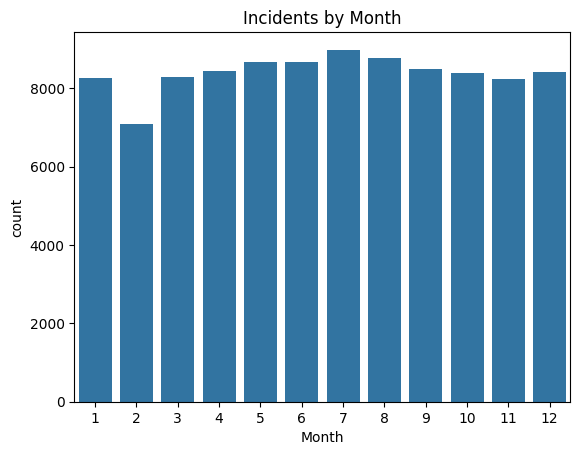

In [ ]:
sns.countplot(x='Month', data=df)
plt.title("Incidents by Month")

## (b) Monthly Incidents by Reason

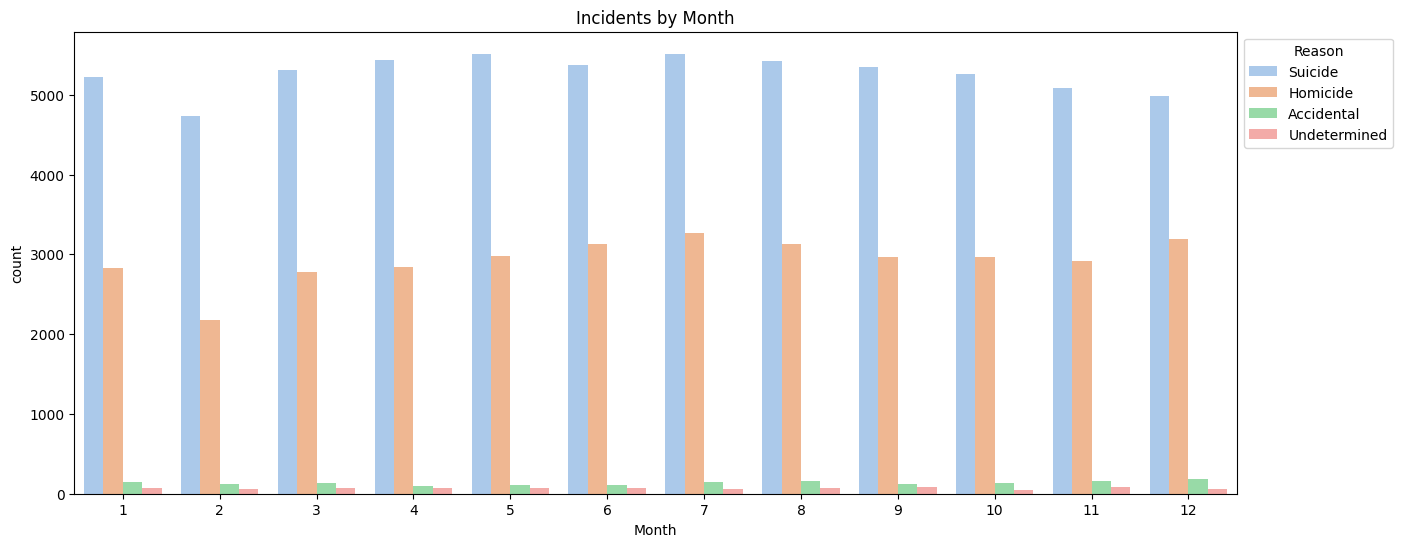

In [ ]:
plt.figure(figsize=(15,6))
sns.countplot(x='Month', hue = 'Reason', data=df, palette = 'pastel', hue_order=['Suicide', 'Homicide', 'Accidental', 'Undetermined'])
plt.title("Incidents by Month")
plt.legend(title="Reason", bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

## (c) Yearly Incidents by Reason

Text(0.5, 1.0, 'Yearly Trend by Reason')

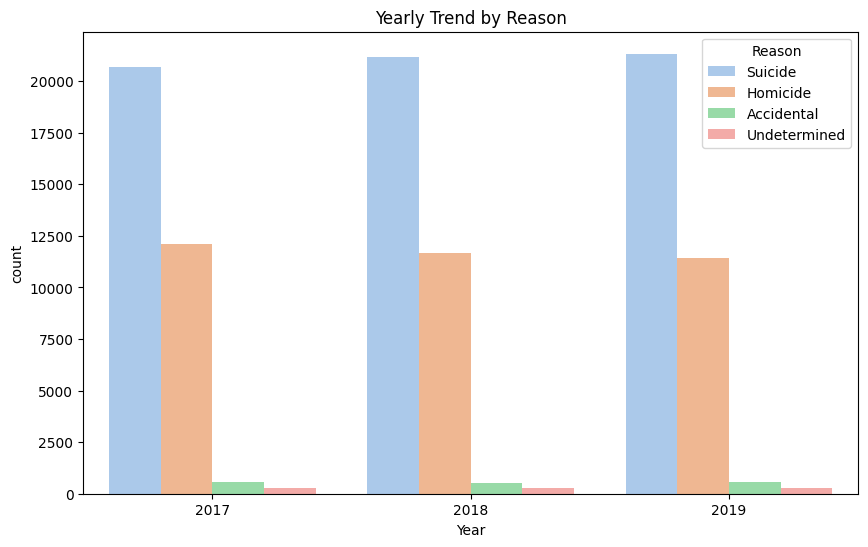

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Year', hue='Reason', data=df, palette = 'pastel', hue_order=['Suicide', 'Homicide', 'Accidental', 'Undetermined'])
plt.title("Yearly Trend by Reason")

## (d) Incident Overtime by Reason

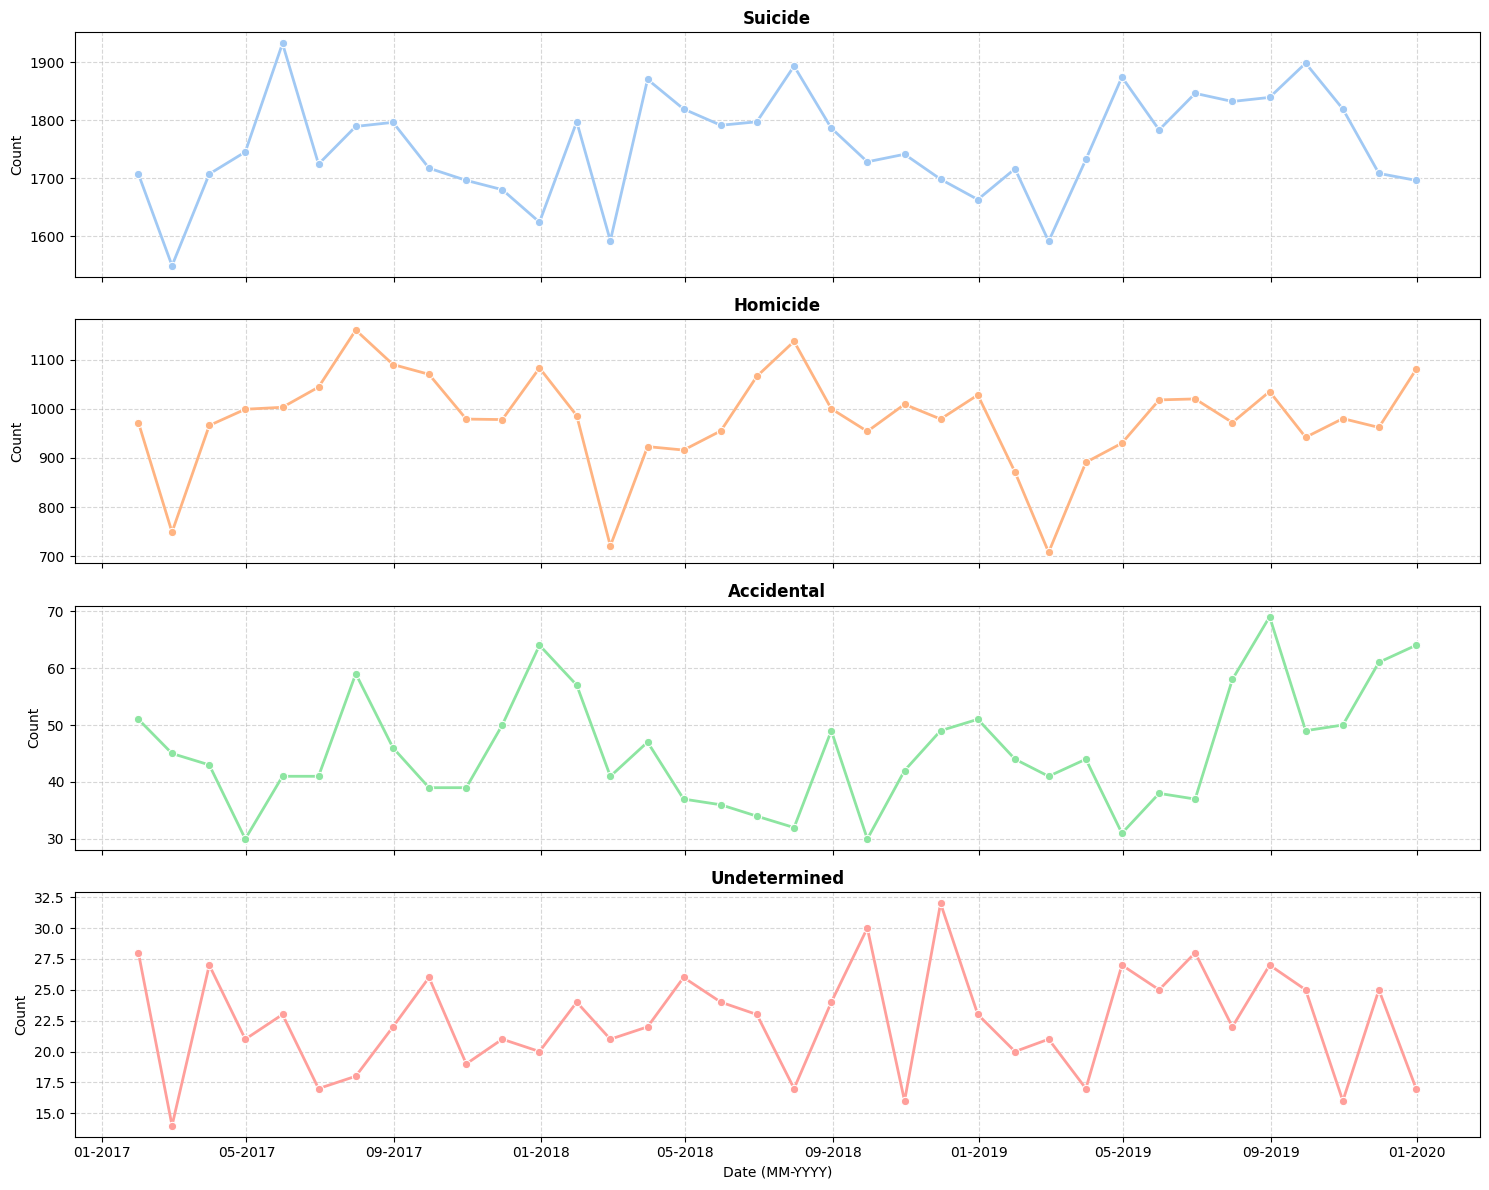

In [ ]:
# Group by Reason and monthly period
trend = df.groupby(['Reason', pd.Grouper(key='Date', freq='ME')]).size().reset_index(name='Count')
reason_order = ['Suicide', 'Homicide', 'Accidental', 'Undetermined']
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# 4 plots, one for each reason
for i, reason in enumerate(reason_order):
    temp = trend[trend['Reason'] == reason]
    sns.lineplot(
        data=temp,
        x='Date', y='Count',
        ax=axes[i],
        marker='o', linewidth=2,
        color=sns.color_palette("pastel", len(reason_order))[i]
    )
    axes[i].set_title(f"{reason}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Count")
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Reformat x axis
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
axes[-1].set_xlabel("Date (MM-YYYY)")

plt.tight_layout()
plt.show()

# Place of Incident

,Place of incident,Count,Percentage (%)
0,Home,60486,60.8
1,Other specified,13751,13.8
2,Street,11151,11.2
3,Other unspecified,8867,8.9
4,Trade/service area,3439,3.5
5,School/instiution,671,0.7
6,Farm,470,0.5
7,Industrial/construction,248,0.2
8,Residential institution,203,0.2
9,Sports,128,0.1


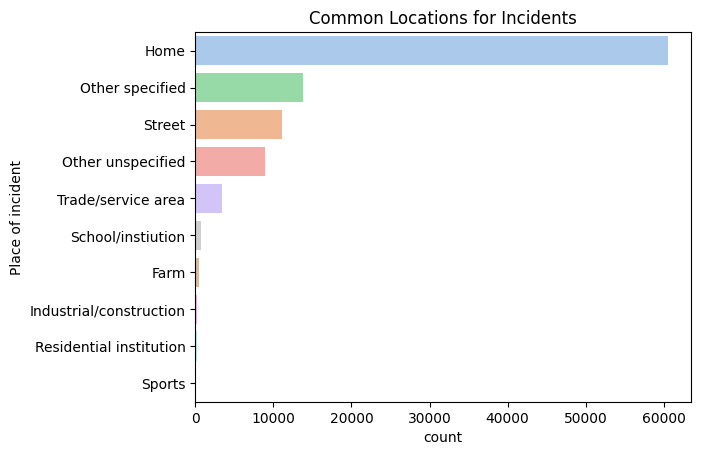

In [ ]:
sns.countplot(y='Place of incident', hue = 'Place of incident', legend = False, data=df, order=df['Place of incident'].value_counts().index, palette = "pastel")
plt.title("Common Locations for Incidents")

# Table count
summary_table = (
    df['Place of incident']
    .value_counts()
    .rename_axis('Place of incident')
    .reset_index(name='Count')
)
summary_table['Percentage (%)'] = (summary_table['Count'] / summary_table['Count'].sum() * 100).round(1)
display(summary_table)

# Police Involvement 

## Police Involvement spread

,Police involvement,Count,Percentage (%)
0,0,99396,98.6
1,1,1402,1.4


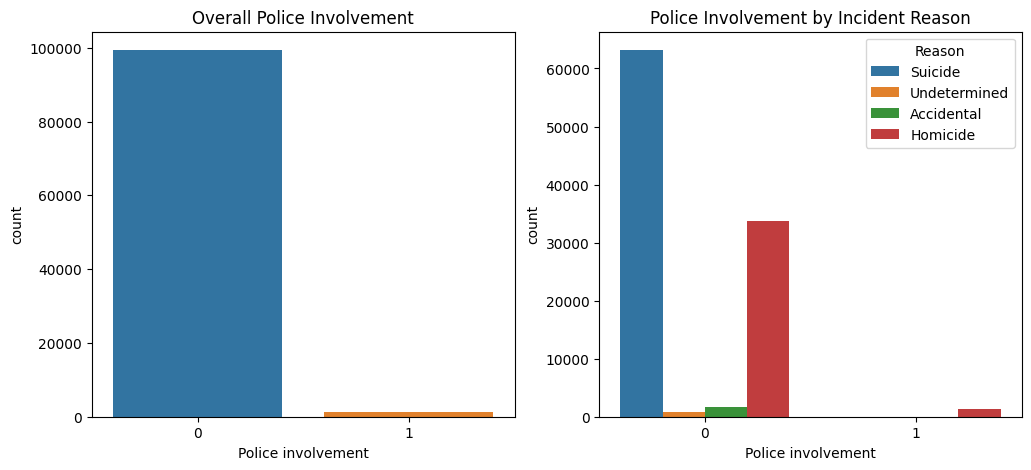

In [ ]:
# Table  of Police Involvement
summary_table = (
    df['Police involvement']
    .value_counts()
    .rename_axis('Police involvement')
    .reset_index(name='Count')
)
summary_table['Percentage (%)'] = (summary_table['Count'] / summary_table['Count'].sum() * 100).round(1)
display(summary_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall police involvement
sns.countplot(x='Police involvement', data=df, ax=axes[0], hue = 'Police involvement', legend = False)
axes[0].set_title("Overall Police Involvement")

# Police involvement by reason
sns.countplot(x='Police involvement', hue='Reason', data=df, ax=axes[1])
axes[1].set_title("Police Involvement by Incident Reason")

plt.show()

From the above table and plot, we can see that there is a imbalance between police involvement in gun incident cases, where 98.6% of gun incidents did not involve police, while the remaining 1.4% of the gun incidents did. Thus for the remaining plots, we will look at the following plots in terms of percentage within whether police is involved or not.

## Police Involvement against Age

<Axes: xlabel='Police involvement', ylabel='Age'>

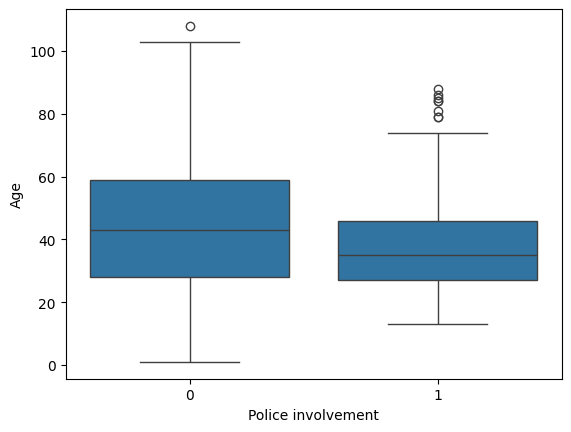

In [ ]:
sns.boxplot(x='Police involvement', y='Age', data=df)

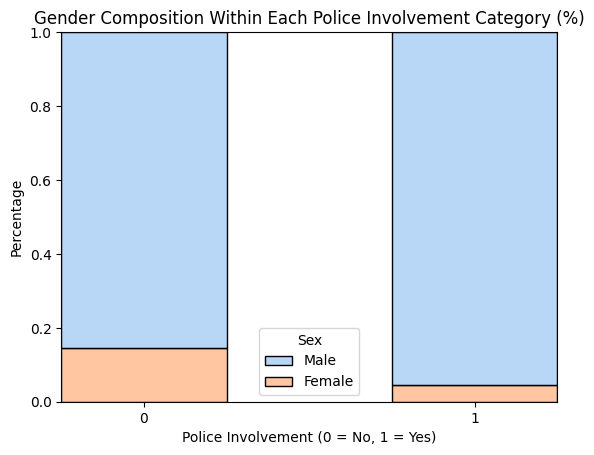

In [ ]:
sns.histplot(
    data = df,
    x = df['Police involvement'].astype(str),
    hue = 'Sex',
    multiple = 'fill',   # each bar = 100%
    stat = 'percent',
    palette = 'pastel',
    shrink = 0.5,
)
plt.title("Gender Composition Within Each Police Involvement Category (%)")
plt.xlabel("Police Involvement (0 = No, 1 = Yes)")
plt.ylabel("Percentage")
plt.show()

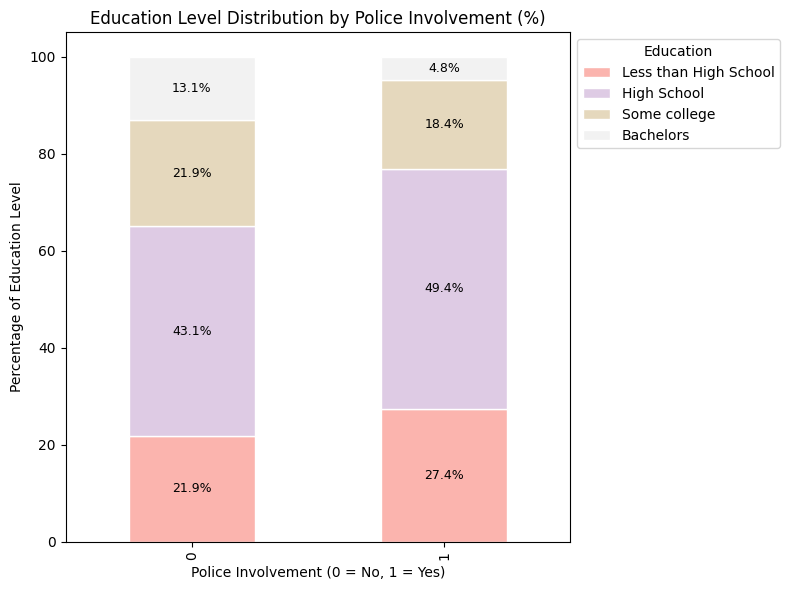

In [ ]:
# Calculate percentage distribution of Education levels by Police involvement
edu_police = pd.crosstab(df['Education'], df['Police involvement'], normalize='columns') * 100
edu_police = edu_police.reindex(education_level)

# Stacked bar chart
ax = edu_police.T.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    colormap='Pastel1',
    edgecolor='white'
)

plt.title("Education Level Distribution by Police Involvement (%)")
plt.xlabel("Police Involvement (0 = No, 1 = Yes)")
plt.ylabel("Percentage of Education Level")
plt.legend(title="Education", bbox_to_anchor=(1, 1), loc='upper left')

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=9,
        color='black'
    )

plt.tight_layout()
plt.show()

## Police Involvement against Place of Incident

In [ ]:
place_police_table = pd.crosstab(df['Place of incident'], df['Police involvement'])

# Add totals and percentages
place_police_table['Total'] = place_police_table.sum(axis=1)
place_police_table['% Police Involved'] = (place_police_table[1] / place_police_table['Total'] * 100).round(1)
place_police_table['% No Police'] = (place_police_table[0] / place_police_table['Total'] * 100).round(1)

# Reorder by most common place
place_police_table = place_police_table.loc[df['Place of incident'].value_counts().index]

# Display
place_police_table

Police involvement,0,1,Total,% Police Involved,% No Police
Place of incident,,,,,
Home,60483,3,60486,0.0,100.0
Other specified,13749,2,13751,0.0,100.0
Street,11146,5,11151,0.0,100.0
Other unspecified,8859,8,8867,0.1,99.9
Trade/service area,3438,1,3439,0.0,100.0
School/instiution,671,0,671,0.0,100.0
Farm,470,0,470,0.0,100.0
Industrial/construction,248,0,248,0.0,100.0
Residential institution,203,0,203,0.0,100.0


## Police Involvement against Reason

Police involvement,0,1,Total,% Police Involved,% No Police
Reason,,,,,
Accidental,1639,0,1639,0.0,100.0
Homicide,33774,1402,35176,4.0,96.0
Suicide,63175,0,63175,0.0,100.0
Undetermined,808,0,808,0.0,100.0


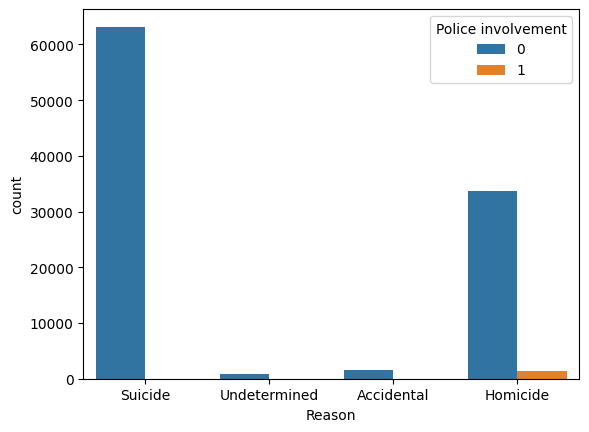

In [ ]:
sns.countplot(x='Reason', hue='Police involvement', data=df)

# table for police involvement by reason
reason_police_table = pd.crosstab(df['Reason'], df['Police involvement'])
reason_police_table['Total'] = reason_police_table.sum(axis=1)
reason_police_table['% Police Involved'] = (reason_police_table[1] / reason_police_table['Total'] * 100).round(1)
reason_police_table['% No Police'] = (reason_police_table[0] / reason_police_table['Total'] * 100).round(1)
reason_police_table